In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from functools import partial
from scipy.integrate import quad, dblquad

import pyccl as ccl
import camb
from camb import model, initialpower
import cosmology
import fisher_matrix_local_png
import fisher_matrix_neutrino_mass
import fisher_matrix_neutrino_mass_full_cosmo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')
s8_z0 = ccl.sigma8(cosmo)

In [9]:
zarray=np.linspace(2,4,350)
nz=np.exp(-((zarray-3)**2/(2*0.5**2)))
bz=3.5*np.ones((350))
Area=15000
N_degm2=1000

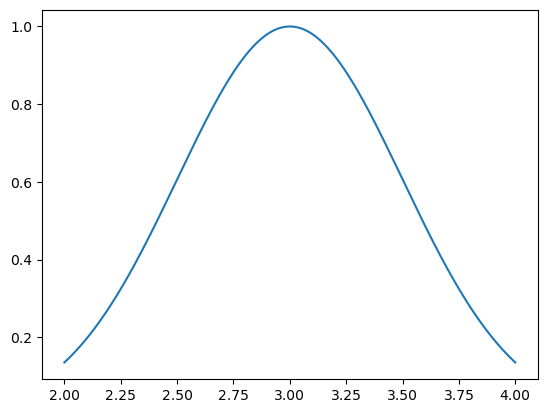

In [10]:
plt.plot(zarray, nz)

In [4]:
s8z = cosmology.sigma_8(zarray,cosmo)

In [47]:
list_zbin, list_sigma_b, list_sigma_mnu_, zeff, sigma_b_eff, sigma_mnu_eff_=fisher_matrix_neutrino_mass.sigma_mnu_single_tracer(zarray,nz,bz,Area,N_degm2,
                                                                                                                                Deltaz=0.1,kmax=0.1,cosmo=cosmo)

Building CAMB interpolators...
Done.


In [24]:
sigma_mnu_eff_

0.03895564859574718

In [27]:
list_zbin, list_sigma_b, list_sigma_mnu, zeff, sigma_b_eff, sigma_mnu_eff, F=fisher_matrix_neutrino_mass_full_cosmo.sigma_mnu_single_tracer_full(zarray,nz,bz,Area,N_degm2,
                                                                                                                                              prior_params=['Mnu', 'H0', 'omega_c', 'omega_b', 'ns', 'As'],
                                                                                                                                              Deltaz=0.1,kmax=0.1,cosmo=cosmo, return_F=True)

Building CAMB derivatives for all cosmological parameters...
  derivative d ln Pm / d Mnu done.
  derivative d ln Pm / d H0 done.
  derivative d ln Pm / d omega_c done.
  derivative d ln Pm / d omega_b done.
  derivative d ln Pm / d ns done.
  derivative d ln Pm / d As done.
Priors applied to: ['Mnu', 'H0', 'omega_c', 'omega_b', 'ns', 'As']
20


In [48]:
sigma_mnu_eff_, sigma_mnu_eff

(0.03895564859574718, 0.040887392116040935)

In [49]:
F.shape

(7, 7)

In [50]:
import numpy as np

def marginalize_first_m(F, n):
    """
    Marginalize over the FIRST (total - n) parameters, keeping the LAST n.

    F: (total, total) Fisher matrix, ordering (marginalized_params..., kept_params...)
    n: number of parameters to KEEP (the last n rows/cols)

    Returns: (n, n) Fisher matrix for the last n parameters,
             marginalized over everything before them.
    """
    F = np.asarray(F)
    total = F.shape[0]
    m = total - n   # number of params being marginalized out (the first m)

    A = F[m:, m:]      # kept-kept block (n x n)      <- last n params
    C = F[m:, :m]      # kept-marginalized block (n x m)
    B = F[:m, :m]      # marginalized-marginalized block (m x m)  <- first m params

    F_marg = A - C @ np.linalg.inv(B) @ C.T
    return F_marg

In [55]:
F_marg = marginalize_first_m(F, 6)

In [59]:
a = np.linalg.inv(F_marg).diagonal()**.5


In [60]:
a

array([4.08873921e-02, 1.12336063e-01, 2.57838196e-04, 3.26950897e-05,
       9.14180223e-04, 6.87386354e-12])